# Employee Attrition Prediction

A machine learning pipeline that predicts which employees are likely to leave a company, and explains which factors drive that risk.

## What this is

An end-to-end classification workflow on HR data: clean and encode raw employee records, train three candidate models, compare them on five metrics, and surface the features that most influence attrition. The goal is not just a prediction, but an explanation an HR team can act on.

```
Raw HR data          Clean & encode         Train 3 models        Explain
     |                     |                      |                   |
     v                     v                      v                   v
Employee.csv  --->  binary + one-hot   --->  LogisticRegression  ---> feature
                     encoded features         DecisionTree            importance
                                               RandomForest            chart
```


## 1. Load and explore

Load `Employee.csv` and check the class balance of the target column (`Attrition`). This dataset is imbalanced — far more employees stayed than left — which is worth keeping in mind when interpreting accuracy later.


In [54]:
# Load the dataset and set pandas to show every column (there are 30+)
import pandas as pd

df = pd.read_csv("Employee.csv")
pd.set_option("display.max_columns", None)

# Quick sanity check: how many employees left ("Yes") vs stayed ("No")?
print("Attrition Distribution\n")
print(df["Attrition"].value_counts(), "\n")
df.head()


Attrition Distribution

Attrition
No     1233
Yes     237
Name: count, dtype: int64 



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 2. Encode binary columns

Convert the two-value text columns (`Attrition`, `Gender`, `OverTime`, `Over18`) into `0`/`1` integers, since scikit-learn models require numeric input.


In [55]:
# Machine learning models need numbers, not text -> convert Yes/No and
# Male/Female style columns into simple 1/0 flags (this is called "binary encoding")
df["Attrition"] = df["Attrition"].apply(lambda x: 1 if x == "Yes" else 0)   # 1 = employee left, 0 = stayed
df["Gender"] = df["Gender"].apply(lambda x: 1 if x == "Male" else 0)        # 1 = Male, 0 = Female
df["OverTime"] = df["OverTime"].apply(lambda x: 1 if x == "Yes" else 0)     # 1 = works overtime
df["Over18"] = df["Over18"].apply(lambda x: 1 if x == "Y" else 0)           # 1 = confirmed over 18

df[["Attrition", "Over18", "Gender", "OverTime"]]


,Attrition,Over18,Gender,OverTime
0,1,1,0,1
1,0,1,1,0
2,1,1,1,1
3,0,1,0,1
4,0,1,1,0
...,...,...,...,...
1465,0,1,1,0
1466,0,1,1,0
1467,0,1,1,1
1468,0,1,1,0


## 3. One-hot encode multi-category columns

`BusinessTravel`, `Department`, `EducationField`, `JobRole`, and `MaritalStatus` each have more than two categories. One-hot encoding avoids implying a false order between them (e.g. `Sales = 1`, `HR = 2`) by giving each category its own binary column.


In [56]:
# Some columns have more than two categories (e.g. Department, JobRole).
# For these we use One-Hot Encoding: each category becomes its own 0/1 column,
# so the model can use them without assuming any category is "bigger" than another.
category_elements = ["BusinessTravel", "Department", "EducationField", "JobRole", "MaritalStatus"]

for Category in category_elements:
    dummy = pd.get_dummies(df[Category], prefix=Category)
    df = pd.concat([df, dummy], axis=1)

# The original text columns are no longer needed once we have their 0/1 versions
df = df.drop(columns=category_elements)
df


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,1,2,0,94,3,2,4,5993,19479,8,1,1,11,3,1,80,0,8,0,1,6,4,0,5,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True
1,49,0,279,8,1,1,2,3,1,61,2,2,2,5130,24907,1,1,0,23,4,4,80,1,10,3,3,10,7,1,7,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
2,37,1,1373,2,2,1,4,4,1,92,2,1,3,2090,2396,6,1,1,15,3,2,80,0,7,3,3,0,0,0,0,False,False,True,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,1,5,4,0,56,3,1,3,2909,23159,1,1,1,11,3,3,80,0,8,3,3,8,7,3,0,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
4,27,0,591,2,1,1,7,1,1,40,3,1,2,3468,16632,9,1,0,12,3,4,80,1,6,3,3,2,2,2,2,False,False,True,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,1,2061,3,1,41,4,2,4,2571,12290,4,1,0,17,3,3,80,1,17,3,3,5,2,0,3,False,True,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False
1466,39,0,613,6,1,1,2062,4,1,42,2,3,1,9991,21457,4,1,0,15,3,1,80,1,9,5,3,7,7,1,7,False,False,True,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False
1467,27,0,155,4,3,1,2064,2,1,87,4,2,2,6142,5174,1,1,1,20,4,2,80,1,6,0,3,6,2,0,3,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False
1468,49,0,1023,2,3,1,2065,4,1,63,2,2,2,5390,13243,2,1,0,14,3,4,80,0,17,3,2,9,6,0,8,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False


## 4. Normalize data types

One-hot encoding produces `bool` columns. Cast them to `int` so every column in the frame is numeric.


In [57]:
# One-hot encoding above creates True/False columns -> convert them to 1/0
# so every column in the dataset is a plain number the model can train on.
for cols in df.columns:
    if df[cols].dtype == bool:
        df[cols] = df[cols].astype(int)
df


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,1,2,0,94,3,2,4,5993,19479,8,1,1,11,3,1,80,0,8,0,1,6,4,0,5,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,1,2,3,1,61,2,2,2,5130,24907,1,1,0,23,4,4,80,1,10,3,3,10,7,1,7,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,1,4,4,1,92,2,1,3,2090,2396,6,1,1,15,3,2,80,0,7,3,3,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,1,5,4,0,56,3,1,3,2909,23159,1,1,1,11,3,3,80,0,8,3,3,8,7,3,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,7,1,1,40,3,1,2,3468,16632,9,1,0,12,3,4,80,1,6,3,3,2,2,2,2,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,1,2061,3,1,41,4,2,4,2571,12290,4,1,0,17,3,3,80,1,17,3,3,5,2,0,3,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0
1466,39,0,613,6,1,1,2062,4,1,42,2,3,1,9991,21457,4,1,0,15,3,1,80,1,9,5,3,7,7,1,7,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0
1467,27,0,155,4,3,1,2064,2,1,87,4,2,2,6142,5174,1,1,1,20,4,2,80,1,6,0,3,6,2,0,3,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
1468,49,0,1023,2,3,1,2065,4,1,63,2,2,2,5390,13243,2,1,0,14,3,4,80,0,17,3,2,9,6,0,8,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0


## 5. Drop non-informative columns

Remove `EmployeeNumber` (an ID), `EmployeeCount` and `StandardHours` (constant across all rows), and `Over18` (constant after encoding). None of these carry predictive signal.


In [58]:
# Drop columns that carry no useful information for prediction:
# - EmployeeNumber: just an ID
# - EmployeeCount / StandardHours: the same value for every row
# - Over18: everyone in this dataset is already an adult
df = df.drop(columns=["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"])

df.head()


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,3,1,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,4,1,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,4,0,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0


## 6. Visualize distributions

Histogram every numeric feature to sanity-check ranges and spot obvious skew before modeling.


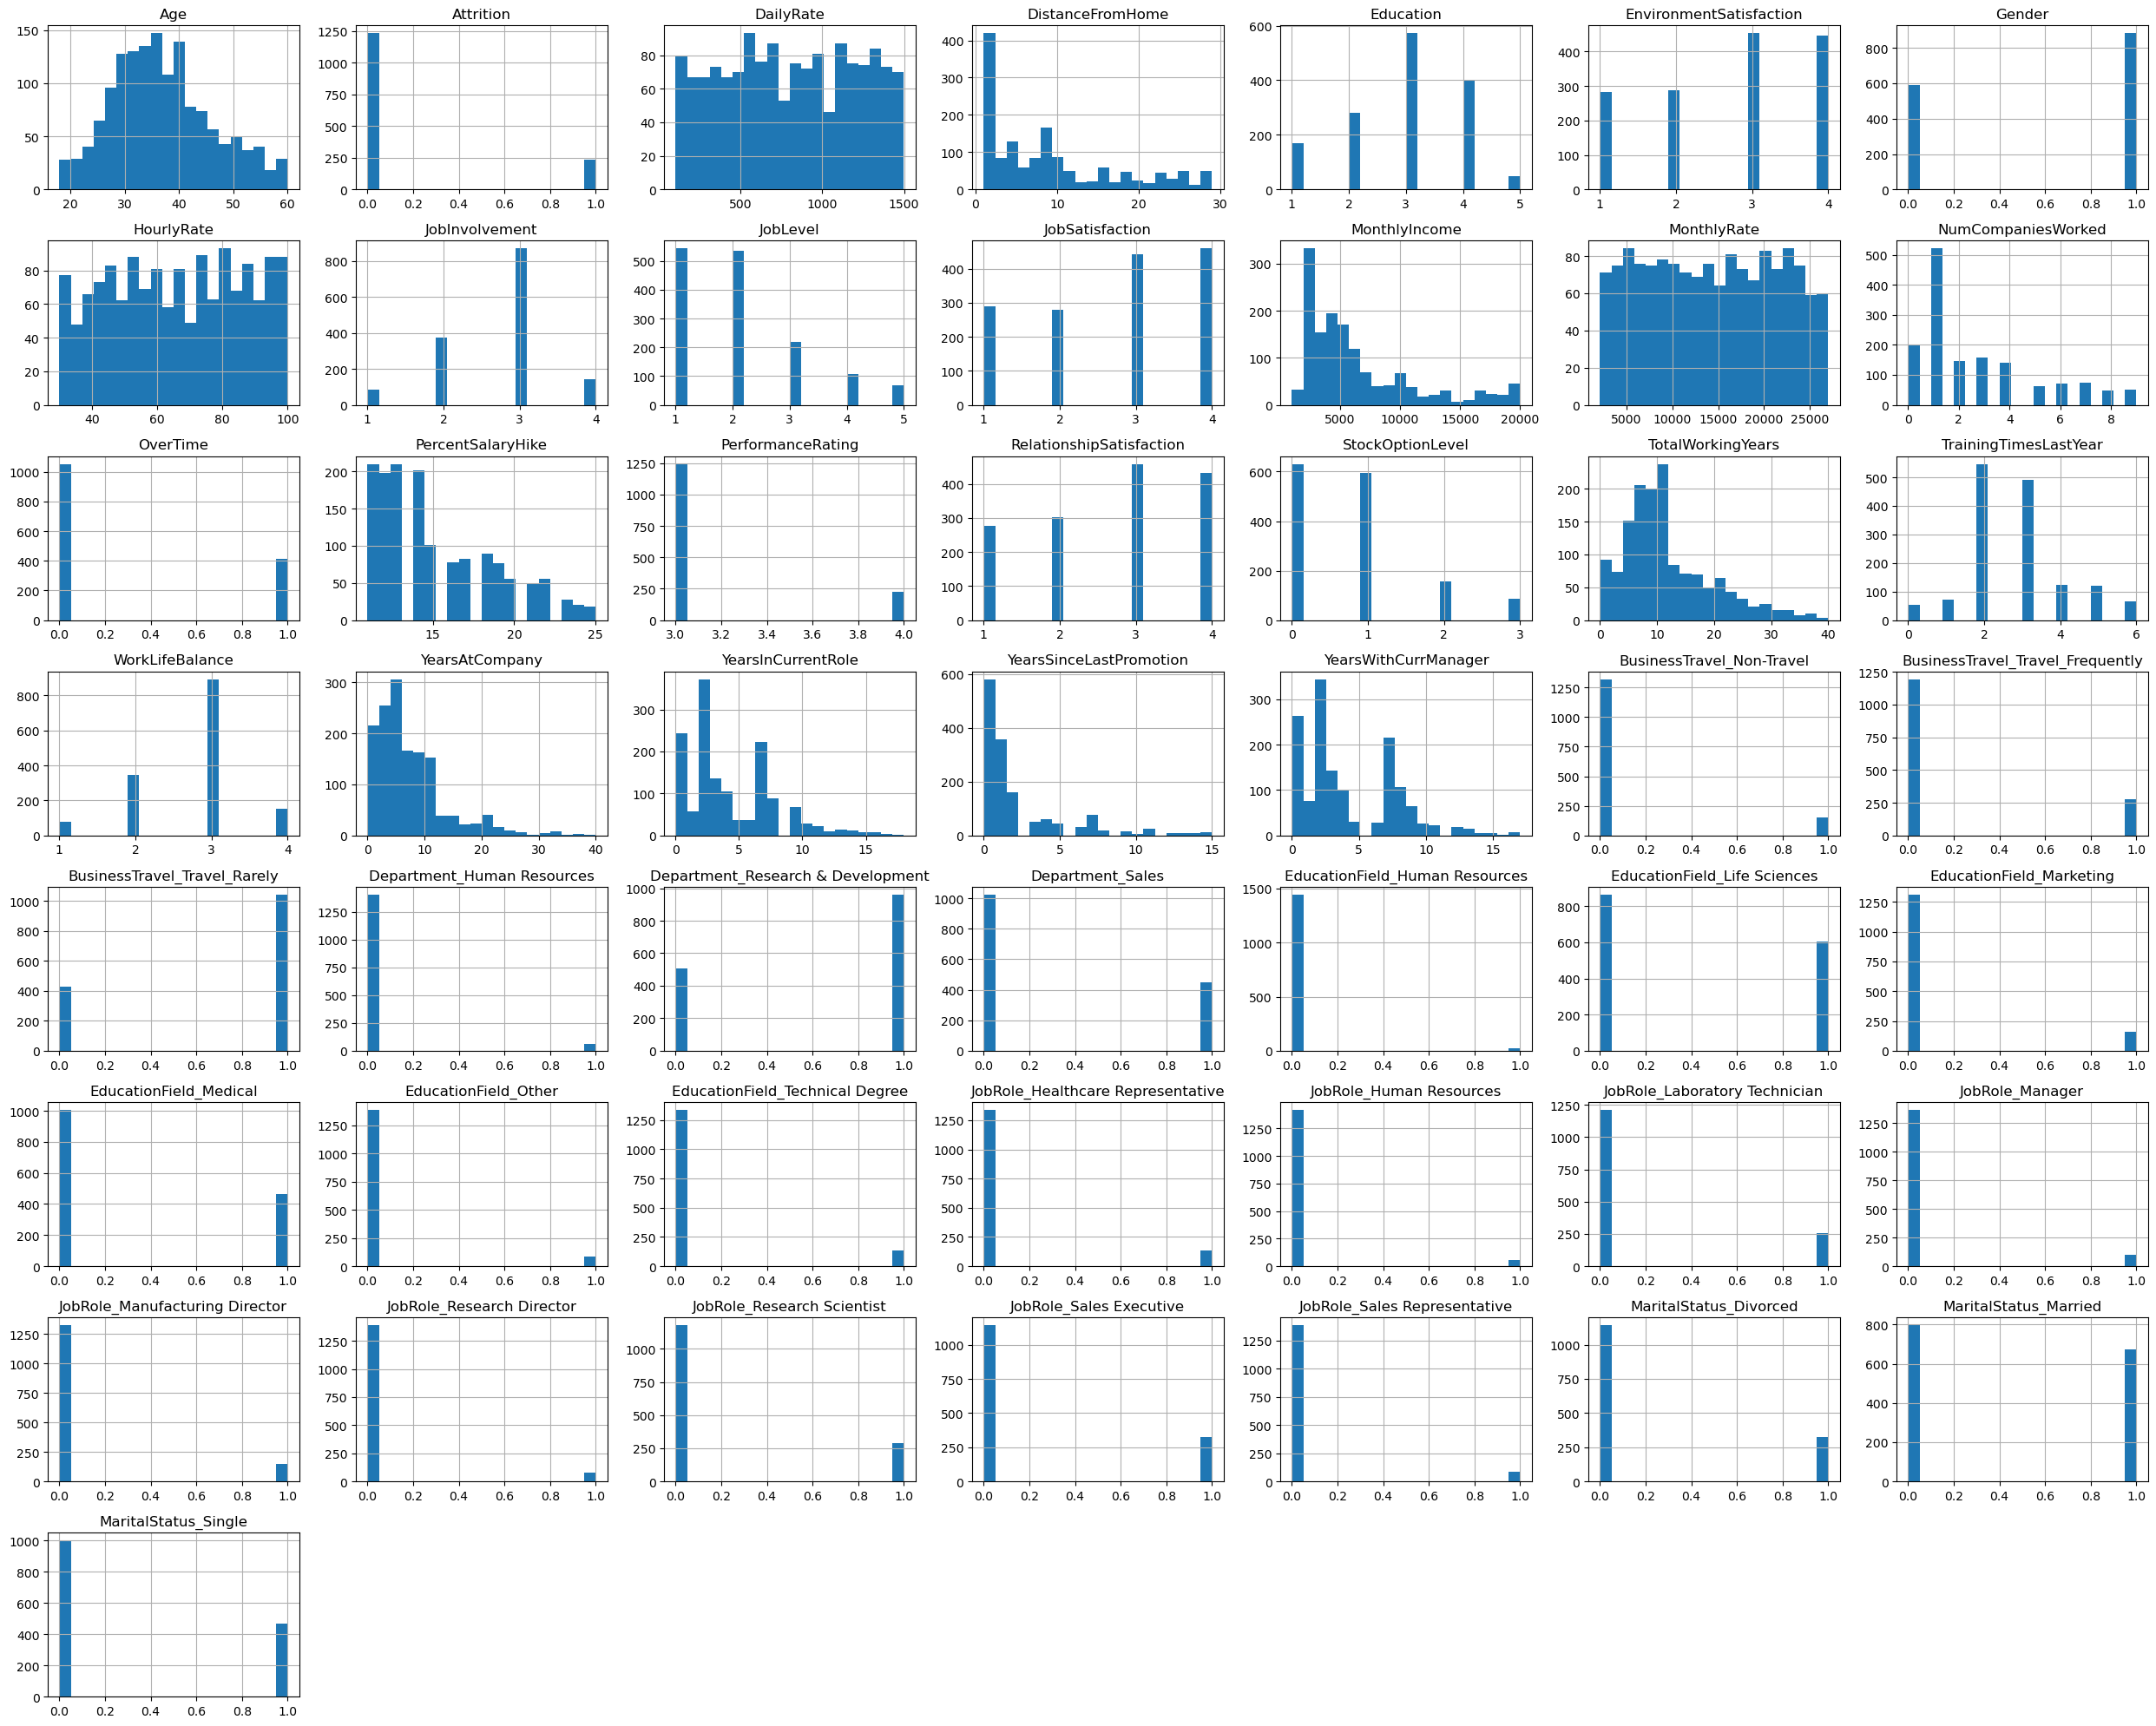

In [59]:
# Plot a histogram for every numeric column to see how each feature is
# distributed (age range, income range, years at company, etc.)
import matplotlib.pyplot as plt

df.hist(figsize=(25, 20), bins=20)
plt.tight_layout()

plt.show()


## 7. Split data and define models

An 80/20 train/test split, stratified on the target so both sets preserve the same attrition ratio. Three candidates are defined for comparison:

| Model | Why it's included |
|---|---|
| `LogisticRegression` | Linear baseline, coefficients are directly interpretable |
| `DecisionTreeClassifier` | Captures non-linear splits, no scaling required |
| `RandomForestClassifier` | Ensemble of trees, typically the strongest raw performer |


In [60]:
# Set up the machine learning pipeline: split the data and define the
# candidate models we want to compare.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# X = everything the model can look at (features), y = what it should predict (target)
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# 80% of employees for training, 20% held back for testing.
# stratify=y keeps the same Yes/No attrition ratio in both sets.
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Three models to compare:
# - Logistic Regression: simple, interpretable baseline (scaled first for best results)
# - Decision Tree: captures non-linear patterns, easy to visualize
# - Random Forest: an ensemble of trees, usually the strongest of the three
models = {
    "LogisticRegression": Pipeline([
        ("Scaler", StandardScaler()),
        ("Model", LogisticRegression(max_iter=1000))
    ]),
    "DecisionTree": DecisionTreeClassifier(random_state=42),

    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}


## 8. Train and compare

Each model is fit on the training set and scored on the held-out test set across five metrics: accuracy, precision, recall, F1, and ROC-AUC. No single metric tells the full story on an imbalanced target, so all five are reported together.


In [61]:
# Train each model on the training data, then test it on unseen data
# and record Accuracy, Precision, Recall, F1 and ROC-AUC for comparison.
results = []


for name, model in models.items():
    model.fit(X_train, Y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(Y_test, y_pred),
        "Precision": precision_score(Y_test, y_pred),
        "Recall": recall_score(Y_test, y_pred),
        "F1 Score": f1_score(Y_test, y_pred),
        "Roc Auc": roc_auc_score(Y_test, y_prob)
    })


results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1 Score,Roc Auc
0,LogisticRegression,0.860544,0.615385,0.340426,0.438356,0.807822
1,DecisionTree,0.772109,0.300000,0.319149,0.309278,0.588724
2,RandomForestClassifier,0.843537,0.571429,0.085106,0.148148,0.770437


## 9. Select the working model

`selected_model` is set to `LogisticRegression` explicitly, prioritizing interpretability over the raw top score in `results_df`. This is a deliberate tradeoff, not a bug — the payoff is the explainable feature-importance chart in the next step.


In [62]:
# Find whichever model scored the highest Accuracy in the table above
Best_Model = results_df.loc[
    results_df["Accuracy"].idxmax()
    ]
Best_Model

# Logistic Regression is picked here because it offers clear, explainable
# coefficients (see the feature-importance chart below), even though Random
# Forest may edge it out slightly on raw accuracy.
selected_model = models["LogisticRegression"]["Model"]
selected_model


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 10. Explain the model

The top 10 features by absolute coefficient weight, signed by direction of effect:

- Red — increases predicted attrition risk
- Green — decreases predicted attrition risk

This is the output most useful to a non-technical audience: it reframes the model from a prediction engine into a diagnostic tool.


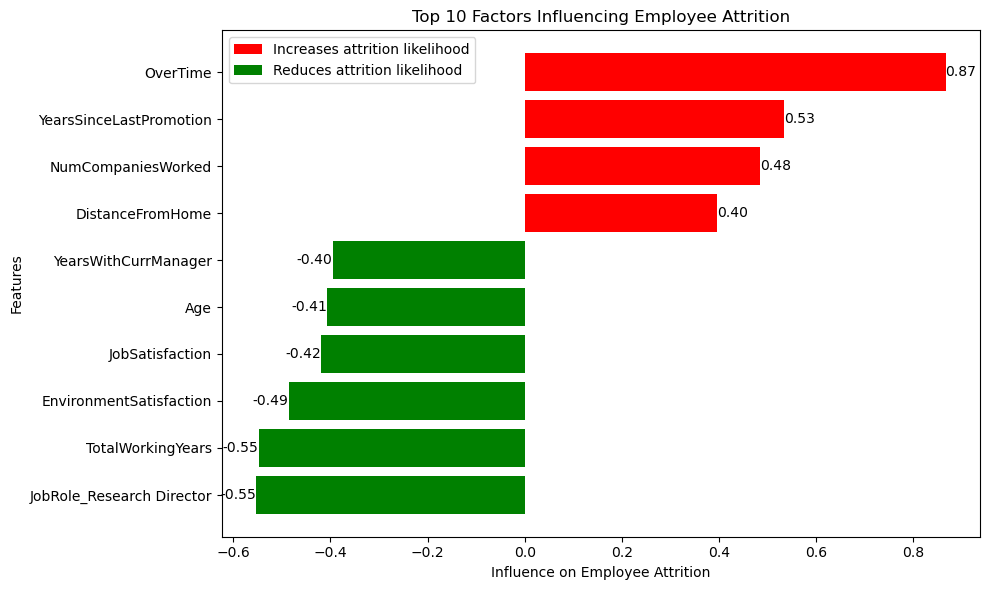

In [63]:
from matplotlib.patches import Patch

# Create feature importance dataframe
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": selected_model.coef_[0]
})

# Add absolute importance for selecting strongest features
importance["Abs_Importance"] = abs(importance["Importance"])

# Select top 10 influential features
top10 = importance.sort_values(
    by="Abs_Importance",
    ascending=False
).head(10)

# Sort for better visualization
top10 = top10.sort_values(
    by="Importance",
    ascending=True
)

# Colors based on impact
colors = [
    "red" if value > 0 else "green"
    for value in top10["Importance"]
]

# Plot
plt.figure(figsize=(10,6))

bars = plt.barh(
    top10["Feature"],
    top10["Importance"],
    color=colors
)

# Add values on bars
for bar, value in zip(bars, top10["Importance"]):
    plt.text(
        value,
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f}",
        va="center",
        ha="left" if value > 0 else "right"
    )

# Labels and title
plt.xlabel("Influence on Employee Attrition")
plt.ylabel("Features")
plt.title("Top 10 Factors Influencing Employee Attrition")

# Legend
legend_elements = [
    Patch(facecolor="red", label="Increases attrition likelihood"),
    Patch(facecolor="green", label="Reduces attrition likelihood")
]

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()


## Next steps

- Address class imbalance (e.g. `SMOTE` or class-weighted models) — the current split is roughly 6:1 stayed-to-left
- Cross-validate rather than relying on a single train/test split
- Tune hyperparameters for `RandomForestClassifier`, which was not tuned here
- Wrap `selected_model` in a small script or API for repeated scoring on new employee records
